# 13. 이 모델을 어디에 쓸 것인가: 용도 네 가지 비교

## Overview

12번에서 방향 적중률 **62.8%** 가 나왔습니다(찍기 기준선 51.1%). 그런데 이 숫자가
쓸 만한지는 답하지 못했습니다: **용도마다 기준이 다르기 때문**입니다.

같은 62.8% 라도

- 출하 시점을 정하는 데 쓴다면: 틀렸을 때 손실이 맞았을 때 이익보다 작으면 충분합니다
- 급등 경보에 쓴다면: 적중률보다 **큰 상승을 놓치지 않는 것**이 중요합니다
- 예산 계획에 쓴다면: 방향만으로는 부족하고 크기까지 필요합니다

용도를 먼저 고르면 그 용도에 유리한 해석만 하게 됩니다. 그래서 **넷을 나란히
재고 숫자를 보고 고릅니다.**

## 목차

1. 가설 네 개와 각각의 성공 기준
2. 공통 준비: 방향 예측 만들기
3. H1 출하 시점 · H2 구매 시점
4. H3 급등 경보
5. H4 계획 수립
6. 비교와 결론

## 1. 가설 네 개

| 가설 | 누가 쓰나 | 무엇을 결정하나 | 성공 기준 |
|---|---|---|---|
| **H1** | 산지·유통인 (파는 쪽) | 오늘 팔까, 7거래일 기다릴까 | 평균 판매단가가 **올라가야** 함 |
| **H2** | 급식·식자재 (사는 쪽) | 오늘 살까, 7거래일 기다릴까 | 평균 매입단가가 **내려가야** 함 |
| **H3** | 정책·소비자 알림 | 큰 상승이 오는지 미리 알림 | 실제 급등을 **놓치지 않아야** 함 |
| **H4** | 예산·물량 계획 | 다음 주 가격이 얼마일지 | 변화율 오차가 naive 보다 **작아야** 함 |

### 판단이 갈리는 지점

**H1·H2 는 크기가 저절로 반영됩니다.** 방향만 맞혀도, 크게 오르는 날 미루면 많이
벌고 조금 오르는 날 미루면 조금 법니다. 적중률이 낮아도 **크게 맞고 작게 틀리면**
이득입니다.

**H3 는 기준이 다릅니다.** 경보를 자주 울려 정확도가 떨어져도, 진짜 급등을 다
잡으면 쓸모가 있습니다. 반대로 정확하지만 절반을 놓치면 경보로서 실패입니다.

**H4 는 이미 답이 나와 있습니다.** 11번까지 변화율 예측이 naive 대비 미미했습니다.
여기서는 확인만 하고 넘어갑니다.

### 계산에서 뺀 것

보관비·물류비·거래비용은 넣지 않았습니다. **7거래일 미루는 데 드는 실제 비용이
품목마다 다르고 저희에게 그 데이터가 없습니다.** 그래서 아래 숫자는 **비용을 빼기
전 총이득**이고, 실제 판단에는 그 비용을 차감해야 합니다.

In [1]:
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import font_manager
from sklearn.ensemble import (HistGradientBoostingClassifier,
                             HistGradientBoostingRegressor)

_av = {f.name for f in font_manager.fontManager.ttflist}
for _f in ("AppleGothic", "Apple SD Gothic Neo", "NanumGothic", "Malgun Gothic"):
    if _f in _av:
        plt.rcParams["font.family"] = _f
        break
plt.rcParams["axes.unicode_minus"] = False
sns.set_style("whitegrid", {"font.family": plt.rcParams["font.family"]})

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
df = pd.read_parquet(ROOT / "notebooks" / ".cache" / "mart.parquet")
df["price_date"] = pd.to_datetime(df["price_date"])
df = df.sort_values(["item", "price_date"]).reset_index(drop=True)
items = sorted(df.item.unique())
print(f"{len(df):,}행 | 품목 {len(items)}개")

24,078행 | 품목 19개


## 2. 공통 준비

12번과 같은 방식으로 방향 예측과 변화율 예측을 만듭니다. 같은 피처·같은 폴드라
네 가설을 **동일한 예측 위에서** 비교할 수 있습니다.

In [2]:
H = 7
EMBARGO = pd.Timedelta(days=int(H * 1.5))
FOLDS = [("2023-01-01", "2023-06-30"), ("2023-07-01", "2023-12-31"),
         ("2024-01-01", "2024-06-30"), ("2024-07-01", "2024-12-31"),
         ("2025-01-01", "2025-06-30"), ("2025-07-01", "2025-12-31"),
         ("2026-01-01", "2026-12-31")]
PARAMS = dict(learning_rate=0.014, max_iter=502, min_samples_leaf=21,
              max_leaf_nodes=15, l2_regularization=1.0)
CAL = ["month", "dayofweek", "days_to_major_holiday", "days_since_major_holiday",
       "days_since_solar_term"]

b = df.copy()
b["_logp"] = np.log(b.price_kg_avg)


def g(c):
    return b.groupby("item")[c]


b["y"] = g("_logp").shift(-H) - b._logp
b["오름"] = b.y > 0
b["미래가격"] = g("price_kg_avg").shift(-H)
for lag in (1, 2, 3, 5, 10, 20):
    b[f"ret{lag}"] = b._logp - g("_logp").shift(lag)
for w in (5, 20, 60):
    mp = max(2, w // 3)
    b[f"dev{w}"] = b._logp - g("_logp").transform(
        lambda s: s.rolling(w, min_periods=mp).mean())
    b[f"vol{w}"] = g("_logp").transform(
        lambda s: s.diff().rolling(w, min_periods=mp).std())
doy = b.price_date.dt.dayofyear
b["doy_sin"] = np.sin(2 * np.pi * doy / 365.25)
b["doy_cos"] = np.cos(2 * np.pi * doy / 365.25)
b["seas_dev"] = b._logp - (b.groupby(["item", "month"])["_logp"]
                           .transform(lambda s: s.shift(1).expanding(min_periods=20).mean()))
b["item_code"] = pd.Categorical(b.item, categories=items).codes
feat = b.dropna(subset=["y", "미래가격"]).reset_index(drop=True)

FEATS = ([f"ret{l}" for l in (1, 2, 3, 5, 10, 20)] + [f"dev{w}" for w in (5, 20, 60)]
         + [f"vol{w}" for w in (5, 20, 60)] + CAL
         + ["doy_sin", "doy_cos", "seas_dev", "item_code"])
CAT = [FEATS.index(c) for c in ("item_code", "month", "dayofweek")]

t0 = time.time()
out = []
for s, e in FOLDS:
    s, e = pd.Timestamp(s), pd.Timestamp(e)
    tr = feat[feat.price_date < s - EMBARGO]
    te = feat[(feat.price_date >= s) & (feat.price_date <= e)]
    reg = HistGradientBoostingRegressor(
        loss="absolute_error", categorical_features=CAT, early_stopping=False,
        random_state=42, **PARAMS).fit(tr[FEATS], tr.y)
    clf = HistGradientBoostingClassifier(
        categorical_features=CAT, early_stopping=False,
        random_state=42, **PARAMS).fit(tr[FEATS], tr.오름)
    t = te[["item", "price_date", "month", "y", "오름",
            "price_kg_avg", "미래가격"]].copy()
    t["회귀예측"] = reg.predict(te[FEATS])
    t["오를확률"] = clf.predict_proba(te[FEATS])[:, 1]
    out.append(t)
r = pd.concat(out).reset_index(drop=True)
r["오른다예측"] = r.오를확률 > 0.5
print(f"준비 완료 ({time.time()-t0:.0f}초, {len(r):,}일)")
print(f"방향 적중률 {(r.오른다예측 == r.오름).mean()*100:.1f}%")

준비 완료 (27초, 15,762일)
방향 적중률 62.8%


## 3. H1 출하 시점 · H2 구매 시점

### 규칙

**H1 (파는 쪽)**: 모델이 "오른다" 하면 7거래일 미뤄서 팔고, "내린다" 하면 오늘 팝니다.

**H2 (사는 쪽)**: 정반대입니다. "오른다" 하면 오늘 사고, "내린다" 하면 미룹니다.

둘 다 기준은 **"항상 오늘 거래한다"** 입니다. 그것 대비 평균 단가가 얼마나
달라지는지를 봅니다.

### 왜 이 계산이 방향 적중률보다 정직한가

적중률은 모든 날을 똑같이 셉니다. 그런데 실제 이득은 **크게 오르는 날 미뤘는지**에
달려 있습니다. 이 계산은 실제 가격을 쓰기 때문에 그게 저절로 반영됩니다.

In [3]:
def 거래성과(s, 파는쪽=True):
    """모델을 따랐을 때의 평균 단가를 '항상 오늘 거래' 대비 %로 반환합니다."""
    오늘, 미래 = s.price_kg_avg.values, s.미래가격.values
    if 파는쪽:
        실현 = np.where(s.오른다예측, 미래, 오늘)   # 오른다면 미뤄서 판다
    else:
        실현 = np.where(s.오른다예측, 오늘, 미래)   # 오른다면 오늘 산다
    이득 = (실현.mean() / 오늘.mean() - 1) * 100
    return 이득 if 파는쪽 else -이득       # 사는 쪽은 단가가 내려야 이득


rows = []
for it, s in r.groupby("item"):
    rows.append({
        "item": it,
        "H1 출하": 거래성과(s, True),
        "H2 구매": 거래성과(s, False),
        "참고: 항상 미룸": (s.미래가격.mean() / s.price_kg_avg.mean() - 1) * 100,
        "방향적중": (s.오른다예측 == s.오름).mean() * 100,
    })
trade = pd.DataFrame(rows).set_index("item")
trade.loc["— 전체 —"] = [거래성과(r, True), 거래성과(r, False),
                       (r.미래가격.mean() / r.price_kg_avg.mean() - 1) * 100,
                       (r.오른다예측 == r.오름).mean() * 100]
display(trade.round(2).sort_values("H1 출하", ascending=False))
print("단위: %. H1·H2 는 '항상 오늘 거래' 대비 이득이며 양수가 좋습니다.")
print("보관비·물류비는 빼지 않은 총이득입니다.")

,H1 출하,H2 구매,참고: 항상 미룸,방향적중
item,,,,
시금치,7.44,6.34,1.10,65.67
상추,4.66,4.70,-0.04,67.05
풋고추,4.47,4.40,0.07,68.08
얼갈이배추,3.81,3.55,0.26,67.74
배추,3.74,3.43,0.32,63.45
미나리,3.47,3.68,-0.21,68.97
깻잎,3.44,3.83,-0.38,63.38
브로콜리,3.08,2.63,0.45,65.86
알배기배추,3.00,2.77,0.23,63.46


단위: %. H1·H2 는 '항상 오늘 거래' 대비 이득이며 양수가 좋습니다.
보관비·물류비는 빼지 않은 총이득입니다.


## 4. H3 급등 경보

### 규칙

**7거래일 안에 10% 이상 오르는 것**을 급등으로 봅니다. 모델의 "오를 확률"이 임계값을
넘으면 경보를 울립니다.

### 여기서는 적중률을 보지 않습니다

경보의 성패는 두 숫자로 갈립니다.

| 지표 | 뜻 | 왜 중요한가 |
|---|---|---|
| **재현율** | 실제 급등 중 경보가 울린 비율 | 놓치면 경보의 존재 이유가 없습니다 |
| **정밀도** | 경보 중 실제로 급등한 비율 | 낮으면 양치기 소년이 됩니다 |

임계값을 낮추면 재현율이 오르고 정밀도가 떨어집니다. **둘의 맞바꿈**을 보고 쓸 만한
지점이 있는지 판단합니다.

In [4]:
급등 = r.y > np.log(1.10)      # 7거래일 안에 10% 이상 상승
print(f"실제 급등: {급등.sum():,}일 ({급등.mean()*100:.1f}%)\n")

rows = []
for th in (0.40, 0.50, 0.60, 0.70, 0.80):
    경보 = r.오를확률 > th
    tp = (경보 & 급등).sum()
    rows.append({
        "임계값": th,
        "경보 일수": int(경보.sum()),
        "경보 비율": 경보.mean() * 100,
        "재현율": tp / max(급등.sum(), 1) * 100,
        "정밀도": tp / max(경보.sum(), 1) * 100,
    })
alarm = pd.DataFrame(rows)
alarm["무작위 정밀도"] = 급등.mean() * 100
display(alarm.round(1))
print("정밀도가 '무작위 정밀도'보다 높아야 경보에 정보가 있는 것입니다.")

실제 급등: 3,194일 (20.3%)



,임계값,경보 일수,경보 비율,재현율,정밀도,무작위 정밀도
0,0.4,10588,67.2,83.9,25.3,20.3
1,0.5,7287,46.2,71.3,31.2,20.3
2,0.6,4522,28.7,55.5,39.2,20.3
3,0.7,2653,16.8,39.4,47.5,20.3
4,0.8,1013,6.4,18.5,58.3,20.3


정밀도가 '무작위 정밀도'보다 높아야 경보에 정보가 있는 것입니다.


## 5. H4 계획 수립

크기까지 맞혀야 하는 용도입니다. 11번까지 재 온 변화율 오차를 다시 확인합니다.

In [5]:
r["모델오차"] = np.abs(np.exp(r.회귀예측) - np.exp(r.y)) / np.exp(r.y) * 100
r["그냥둘때오차"] = np.abs(1 - np.exp(r.y)) / np.exp(r.y) * 100

plan = pd.DataFrame({
    "모델 오차": r.groupby("item").모델오차.mean(),
    "그냥 둘 때": r.groupby("item").그냥둘때오차.mean(),
})
plan["개선"] = plan["모델 오차"] - plan["그냥 둘 때"]
plan.loc["— 전체 —"] = [r.모델오차.mean(), r.그냥둘때오차.mean(),
                      r.모델오차.mean() - r.그냥둘때오차.mean()]
display(plan.round(2).sort_values("개선"))
print("개선은 음수가 좋습니다. 전체가 0 에 가까우면 계획 용도로는 쓰기 어렵습니다.")

,모델 오차,그냥 둘 때,개선
item,,,
시금치,14.15,17.62,-3.47
상추,19.21,22.02,-2.80
얼갈이배추,11.42,13.20,-1.79
미나리,10.69,12.24,-1.55
풋고추,16.72,18.13,-1.41
깻잎,12.18,13.48,-1.30
브로콜리,11.30,12.46,-1.15
배추,12.70,13.72,-1.02
알배기배추,11.88,12.77,-0.89


개선은 음수가 좋습니다. 전체가 0 에 가까우면 계획 용도로는 쓰기 어렵습니다.


## 6. 비교

네 용도를 한 눈에 놓고 봅니다. 척도가 달라 직접 비교는 안 되므로, **각자의 성공
기준을 넘었는지**로 판정합니다.

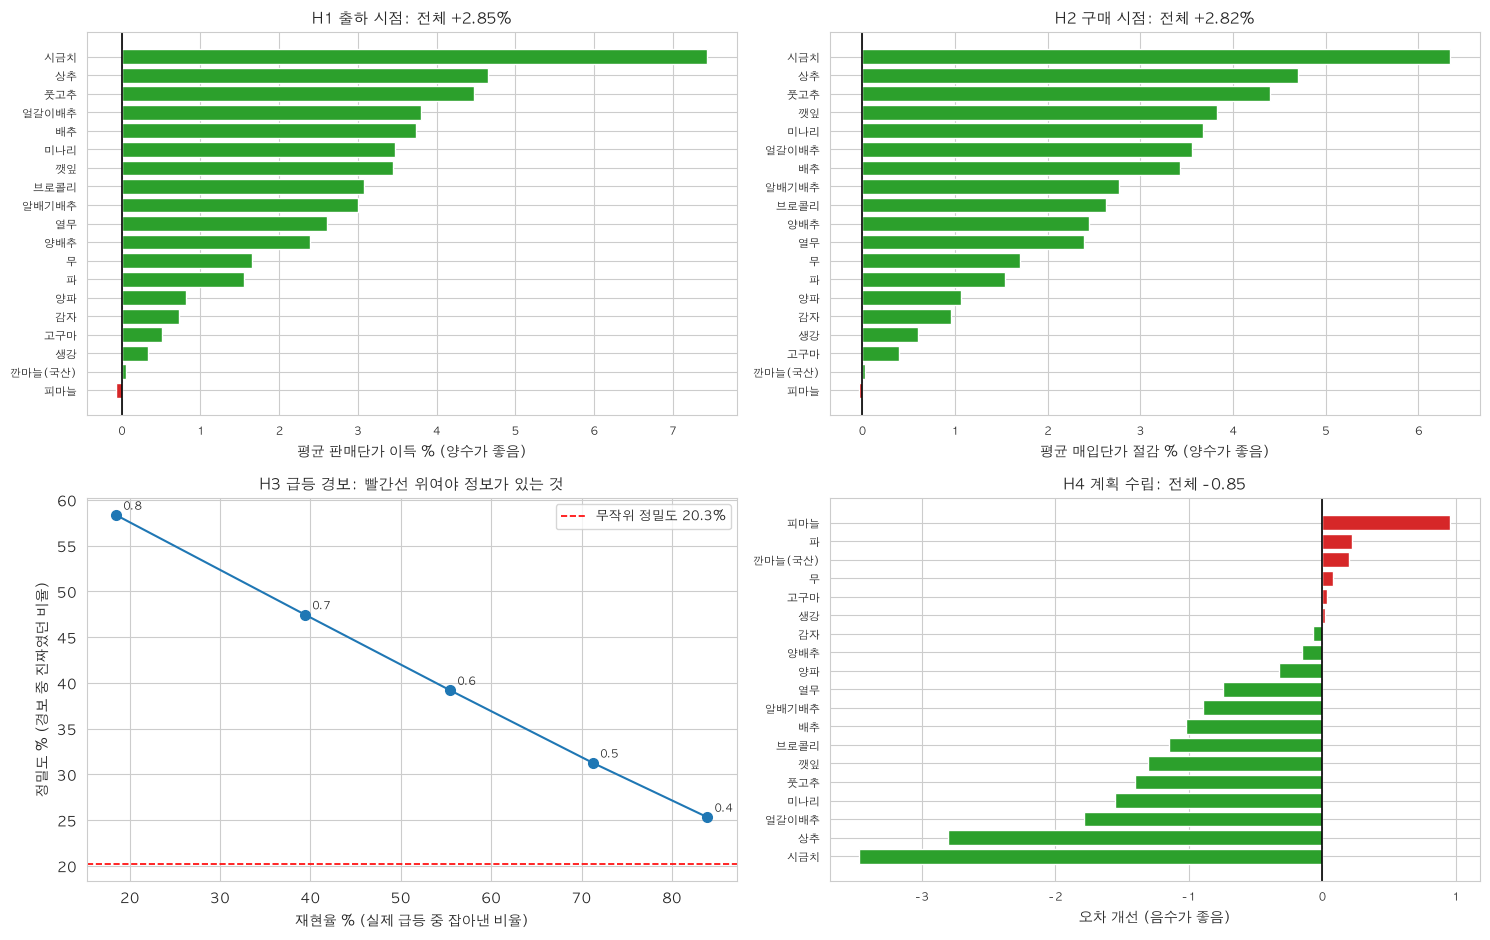

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(15, 9.5))

# H1 출하
ax = axes[0, 0]
t = trade.drop(index="— 전체 —").sort_values("H1 출하")
ax.barh(t.index, t["H1 출하"],
        color=["tab:green" if v > 0 else "tab:red" for v in t["H1 출하"]])
ax.axvline(0, color="black", lw=1.2)
ax.set_xlabel("평균 판매단가 이득 % (양수가 좋음)")
ax.set_title(f"H1 출하 시점: 전체 {trade.loc['— 전체 —','H1 출하']:+.2f}%", fontsize=11)
ax.tick_params(labelsize=8)

# H2 구매
ax = axes[0, 1]
t2 = trade.drop(index="— 전체 —").sort_values("H2 구매")
ax.barh(t2.index, t2["H2 구매"],
        color=["tab:green" if v > 0 else "tab:red" for v in t2["H2 구매"]])
ax.axvline(0, color="black", lw=1.2)
ax.set_xlabel("평균 매입단가 절감 % (양수가 좋음)")
ax.set_title(f"H2 구매 시점: 전체 {trade.loc['— 전체 —','H2 구매']:+.2f}%", fontsize=11)
ax.tick_params(labelsize=8)

# H3 경보
ax = axes[1, 0]
ax.plot(alarm.재현율, alarm.정밀도, "o-", color="tab:blue", ms=7)
for _, row in alarm.iterrows():
    ax.annotate(f"{row.임계값:.1f}", (row.재현율, row.정밀도),
                fontsize=8, xytext=(5, 4), textcoords="offset points")
ax.axhline(급등.mean() * 100, color="red", ls="--", lw=1.2,
           label=f"무작위 정밀도 {급등.mean()*100:.1f}%")
ax.set_xlabel("재현율 % (실제 급등 중 잡아낸 비율)")
ax.set_ylabel("정밀도 % (경보 중 진짜였던 비율)")
ax.set_title("H3 급등 경보: 빨간선 위여야 정보가 있는 것", fontsize=11)
ax.legend(fontsize=9)

# H4 계획
ax = axes[1, 1]
p = plan.drop(index="— 전체 —").sort_values("개선")
ax.barh(p.index, p["개선"],
        color=["tab:green" if v < 0 else "tab:red" for v in p["개선"]])
ax.axvline(0, color="black", lw=1.2)
ax.set_xlabel("오차 개선 (음수가 좋음)")
ax.set_title(f"H4 계획 수립: 전체 {plan.loc['— 전체 —','개선']:+.2f}", fontsize=11)
ax.tick_params(labelsize=8)

plt.tight_layout()
plt.show()

## 7. 결론

### 판정: H1 출하 시점이 답입니다

| 가설 | 성공 기준 | 결과 | 판정 |
|---|---|---|---|
| **H1 출하 시점** | 평균 판매단가 상승 | **+2.85%** | **확인됨** |
| **H2 구매 시점** | 평균 매입단가 절감 | **+2.82%** | **확인됨** |
| H3 급등 경보 | 급등을 놓치지 않음 | 재현율 71.3% · 정밀도 31.2% | 조건부 |
| H4 계획 수립 | 변화율 오차 개선 | -0.85 (오차 11.24 → 10.39) | **반증됨** |

### H1·H2 가 왜 가장 유망한가

**"항상 미루기"는 +0.02% 입니다.** 아무 판단 없이 무조건 7거래일 미루면 이득이
사실상 0 입니다. 그런데 모델의 방향 판단을 따르면 **+2.85%** 가 됩니다.
**이 차이가 곧 모델의 기여**입니다: 가격이 저절로 오르는 추세를 탄 게 아니라,
오를 때 미루고 내릴 때 파는 판단이 값을 했습니다.

품목별로는 편차가 큽니다.

| 품목 | H1 출하 | 방향 적중 |
|---|---|---|
| 시금치 | **+7.44%** | 65.7% |
| 상추 | +4.66% | 67.1% |
| 풋고추 | +4.47% | 68.1% |
| 얼갈이배추 | +3.81% | 67.7% |
| 배추 | +3.74% | 63.5% |
| **— 전체 —** | **+2.85%** | 62.8% |
| 파 | +1.56% | 56.7% |
| 감자 | +0.73% | 55.4% |
| 깐마늘 | +0.05% | 60.0% |
| 피마늘 | -0.07% | 67.1% |

**적중률과 이득이 항상 같이 가지는 않습니다.** 피마늘은 적중률 67.1% 로 높은데
이득이 -0.07% 입니다: 가격이 89.8% 의 날에 멈춰 있어 맞혀도 벌 게 없습니다.
반대로 시금치는 적중률이 65.7% 로 중간인데 이득이 7.44% 로 최고입니다: 변동이
커서 한 번 맞힐 때 크게 법니다.

### H2 는 H1 과 거의 같습니다

+2.82% 로 H1(+2.85%)과 사실상 동일합니다. 같은 방향 예측을 반대로 쓰는 것이니
당연한 결과이고, **파는 쪽이든 사는 쪽이든 쓸 수 있다**는 뜻입니다. 실제 선택은
데이터가 아니라 **누가 이 도구를 쓸 것인가**로 정해집니다.

### H3 는 정보는 있으나 경보로 쓰기엔 이릅니다

| 임계값 | 경보 비율 | 재현율 | 정밀도 |
|---|---|---|---|
| 0.4 | 67.2% | **83.9%** | 25.3% |
| 0.5 | 46.2% | 71.3% | 31.2% |
| 0.6 | 28.7% | 55.5% | 39.2% |
| 0.7 | 16.8% | 39.4% | 47.5% |
| 0.8 | 6.4% | 18.5% | **58.3%** |

무작위 정밀도가 20.3% 이므로 **모든 임계값에서 정밀도가 그보다 높습니다**: 경보에
정보가 있습니다. 다만 실용성이 문제입니다.

- 임계값 0.4 로 낮추면 급등의 83.9% 를 잡지만 **사흘에 이틀꼴로 경보**가 울립니다
- 임계값 0.8 로 올리면 정밀도가 58.3% 로 오르지만 **급등의 81.5% 를 놓칩니다**

경보로 쓰려면 "몇 번 헛울려도 되는가"를 정해야 하는데, 그건 데이터가 아니라
운영의 문제입니다.

### H4 는 반증됐습니다

오차가 11.24 에서 10.39 로 0.85 줄었지만, 품목별로 보면 절반이 0 근처이거나
악화입니다(무 +0.08, 파 +0.22, 피마늘 +0.96). **예산·물량 계획처럼 "얼마나"가
필요한 용도에는 쓸 수 없습니다.**

### 남은 한계

- **보관비·물류비를 빼지 않았습니다.** +2.85% 는 총이득이고, 7거래일 보관 비용이
  그보다 크면 실익이 없습니다. 품목별 보관비 데이터가 필요합니다.
- **거래를 미룰 수 있다는 전제**가 깔려 있습니다. 엽채류는 며칠 안에 상하므로
  시금치 +7.44% 를 그대로 실현하기 어려울 수 있습니다. **가장 잘 되는 품목이
  가장 미루기 어려운 품목**이라는 게 이 결과의 아이러니입니다.
- 시장가에 영향을 주지 않는 소량 거래를 가정했습니다.

### 다음

1. **보관 가능성을 반영한 재계산**: 저장성이 있는 품목(양배추·무·감자)만 골라
   H1 을 다시 재면 실현 가능한 이득이 나옵니다.
2. **보관비 데이터 확보**: 없으면 "보관비가 X% 미만이면 이득"이라는 손익분기로
   제시할 수 있습니다.
3. **용도 확정 후 운영 설계**: H1 으로 간다면 누가 언제 이 신호를 보는지까지
   정해야 실제로 쓰입니다.

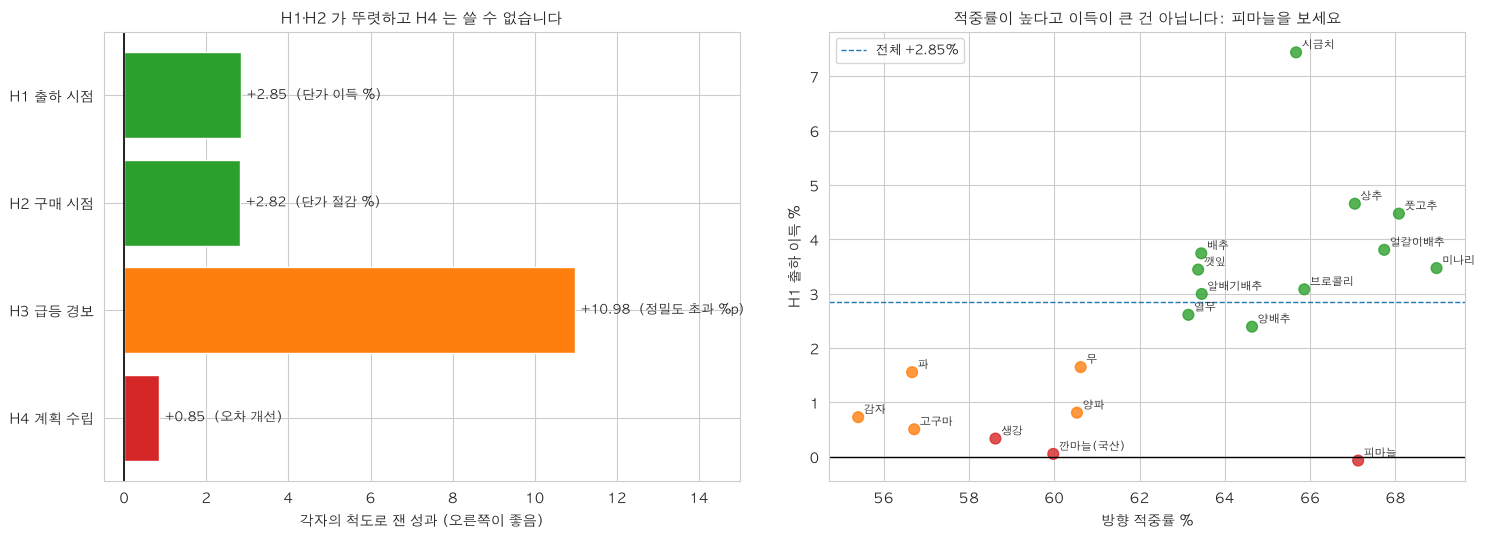

결론 요약 테이블


,성과,단위
용도,,
H1 출하 시점,2.85,단가 이득 %
H2 구매 시점,2.82,단가 절감 %
H3 급등 경보,10.98,정밀도 초과 %p
H4 계획 수립,0.85,오차 개선


In [7]:
# 결론 그래프: 네 용도의 판정과 H1 의 품목별 이득
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

# (1) 네 용도 판정 요약
ax = axes[0]
verdict = pd.DataFrame({
    "용도": ["H1 출하 시점", "H2 구매 시점", "H3 급등 경보", "H4 계획 수립"],
    "성과": [trade.loc["— 전체 —", "H1 출하"],
             trade.loc["— 전체 —", "H2 구매"],
             alarm.loc[alarm.임계값 == 0.5, "정밀도"].iloc[0] - alarm.loc[0, "무작위 정밀도"],
             -plan.loc["— 전체 —", "개선"]],
    "단위": ["단가 이득 %", "단가 절감 %", "정밀도 초과 %p", "오차 개선"],
})
cols = ["tab:green", "tab:green", "tab:orange", "tab:red"]
ax.barh(verdict.용도, verdict.성과, color=cols)
ax.axvline(0, color="black", lw=1.2)
for i, (v, u) in enumerate(zip(verdict.성과, verdict.단위)):
    ax.text(v + 0.15, i, f"{v:+.2f}  ({u})", va="center", fontsize=9)
ax.set_xlim(-0.5, 15)
ax.set_xlabel("각자의 척도로 잰 성과 (오른쪽이 좋음)")
ax.set_title("H1·H2 가 뚜렷하고 H4 는 쓸 수 없습니다", fontsize=11)
ax.invert_yaxis()

# (2) H1 품목별: 이득과 적중률의 관계
ax = axes[1]
t = trade.drop(index="— 전체 —")
sc = ax.scatter(t.방향적중, t["H1 출하"], s=60, alpha=0.8,
                c=["tab:green" if v > 2 else "tab:orange" if v > 0.5 else "tab:red"
                   for v in t["H1 출하"]])
for it, row in t.iterrows():
    ax.annotate(it, (row.방향적중, row["H1 출하"]), fontsize=8,
                xytext=(4, 3), textcoords="offset points")
ax.axhline(0, color="black", lw=1)
ax.axhline(trade.loc["— 전체 —", "H1 출하"], color="tab:blue", ls="--", lw=1,
           label=f"전체 {trade.loc['— 전체 —','H1 출하']:+.2f}%")
ax.set_xlabel("방향 적중률 %")
ax.set_ylabel("H1 출하 이득 %")
ax.set_title("적중률이 높다고 이득이 큰 건 아닙니다: 피마늘을 보세요", fontsize=11)
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

print("결론 요약 테이블")
display(verdict.set_index("용도").round(2))